In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()

In [2]:
X = np.array([
    [1,4, 1.5, 3.8],
    [3,6, 1.0, 3.1],
    [4,7, 0.8, 3.9],
    [5,8, 0.4, 3.4],
    [7,9, 0.2, 2.8]
])


y = np.array([45.9 ,  76.55,  92.35, 107.9 , 128. ])

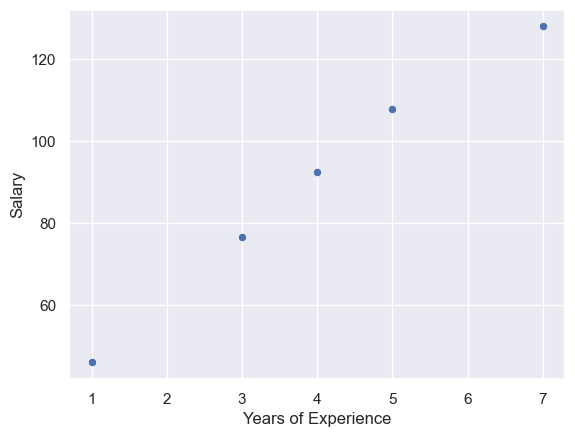

In [3]:
sns.scatterplot(x=X[:,0:1].ravel(), y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

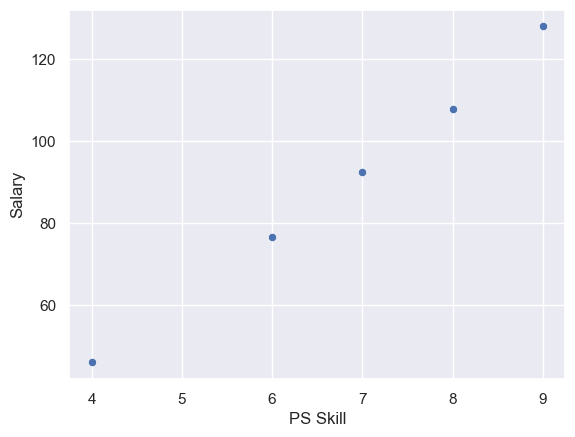

In [4]:
sns.scatterplot(x=X[:,1:2].ravel(), y=y)
plt.xlabel("PS Skill")
plt.ylabel("Salary")
plt.show()

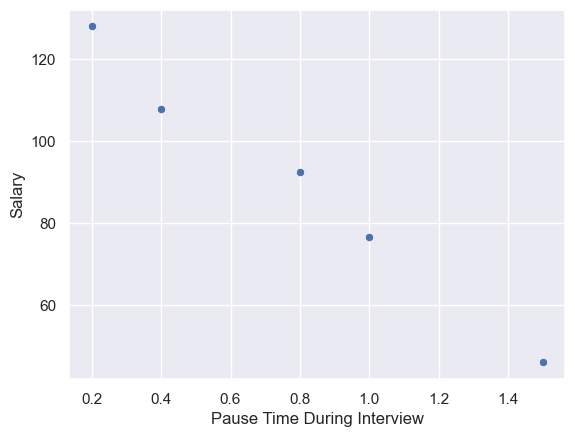

In [5]:
sns.scatterplot(x=X[:,2:3].ravel(), y=y)
plt.xlabel("Pause Time During Interview")
plt.ylabel("Salary")
plt.show()

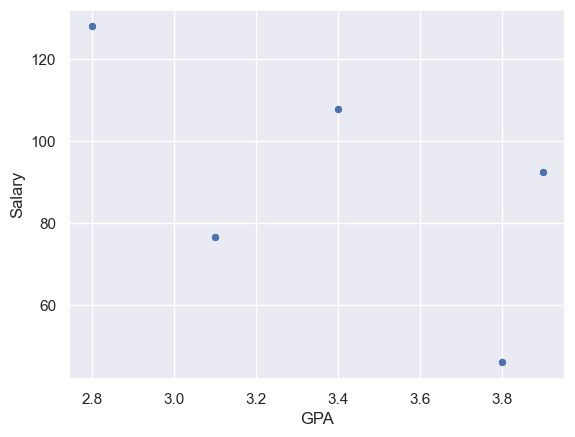

In [6]:
sns.scatterplot(x=X[:,3:].ravel(), y=y)
plt.xlabel("GPA")
plt.ylabel("Salary")
plt.show()

In [7]:
def make_prediction(X, W, b):
 
  m = X.shape[0] 
  pred_list = np.zeros((m,)) 

  for i in range(m):

    pred_list[i] = np.dot(W,X[i]) + b



  return pred_list

In [8]:
m = X.shape[0]
n = X.shape[1]

W_init = np.ones((n,))
b_init = 1.0

make_prediction(X,W_init,b_init)

array([11.3, 14.1, 16.7, 17.8, 20. ])

In [9]:
def compute_cost(X, y, W, b):
  m = X.shape[0]
  cost = 0.0

  pred_list = make_prediction(X,W,b)

  error = pred_list - y

  error_squared = error ** 2

  cost = np.sum(error_squared)

  cost = cost / (2 * m)

  return cost

In [10]:
W_init = np.ones((n,))
b_init = 1.0
compute_cost(X,y, W_init ,b_init)

3060.2095

In [11]:
def calculate_gradient(X, y, W, b):
  
  m = X.shape[0]
  n = X.shape[1]

  dj_dw = np.zeros((n,)) 
  dj_db = 0.0 

  for i in range(m):
    prediction = np.dot(W,X[i]) + b
    error = prediction - y[i]
    dj_db = dj_db +  error

    for j in range(n):
      dj_dw[j] = dj_dw[j] + (error * X[i,j])

  return dj_dw / m, dj_db / m

In [12]:
W_init = np.ones((n,))
b_init = 1.0
calculate_gradient(X,y, W_init ,b_init)

(array([-346.21 , -547.09 ,  -46.502, -245.77 ]), -74.16)

In [13]:
def gradient_descent(X, y, w_input, b_input, max_iter, alpha=0.01):
 
  w = w_input
  b = b_input
  cost_memo = []
  iteration = []

  for i in range(max_iter):
   
    dj_dw, dj_db = calculate_gradient(X, y, w, b)


    w = w - alpha * dj_dw
    b = b - alpha * dj_db

    cost = compute_cost(X,y, w, b)
    cost_memo.append(cost)
    iteration.append(i)

    if i % 100 == 0:
      print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {w}, b: {b:0.4f}")

  return w, b, cost_memo, iteration

In [14]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, w_input=W_init, b_input=b_init, max_iter=100000, alpha=0.01)

Iteration 0: Cost 188.4458,dj_dw: [-416.09  -660.91   -57.608 -299.43 ] ,dj_db : -90.14 w: [4.1609  6.6091  0.57608 2.9943 ], b: 0.9014
Iteration 100: Cost 0.1977,dj_dw: [-0.28972633 -0.05290958  0.24653403  0.43027154] ,dj_db : 0.08612436152810546 w: [ 6.8215041   8.3071171  -0.38008643  1.775159  ], b: 0.7104
Iteration 200: Cost 0.1303,dj_dw: [ 0.02982799 -0.05138487  0.04097921  0.06083368] ,dj_db : 0.007027042739051126 w: [ 6.88604616  8.35924356 -0.48209566  1.60468101], b: 0.6799
Iteration 300: Cost 0.1229,dj_dw: [ 0.05097646 -0.04994653  0.0258774   0.03389236] ,dj_db : 0.001434162447482379 w: [ 6.84103994  8.40989801 -0.51257454  1.56262078], b: 0.6769
Iteration 400: Cost 0.1162,dj_dw: [ 0.05111217 -0.04855146  0.02422668  0.0311383 ] ,dj_db : 0.0010265453320016603 w: [ 6.7896808   8.45913669 -0.53741432  1.53048588], b: 0.6757
Iteration 500: Cost 0.1098,dj_dw: [ 0.04980317 -0.04719556  0.0235398   0.03011513] ,dj_db : 0.0009845325017138861 w: [ 6.7392106   8.50700022 -0.561278

In [15]:
print(w_final)
print(b_final)

# w =[5,10,-2,0.5] , b=2.0

[ 4.9736024  10.14304775 -1.56445471  0.47744225]
0.8695947679498179


In [16]:
X_test=  [2,10, 1.5, 3.8]

prediction_of_new_data = w_final[0] * X_test[0] +w_final[1] * X_test[1] + w_final[2] * X_test[2] + w_final[3] * X_test[3] + b_final

print(prediction_of_new_data)

111.71487549666952


In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import SGDRegressor

In [18]:
model1 = LinearRegression()

model1.fit(X,y)

weights = model1.coef_
bias = model1.intercept_

print(weights)
print(bias)

[ 5.  10.  -2.   0.5]
2.000000000000213


In [19]:
model2 = SGDRegressor(penalty=None,max_iter=10000000,learning_rate="constant")

model2.fit(X,y)


weights= model2.coef_
bias = model2.intercept_

print(weights)
print(bias)

[ 7.00433152  8.15663607 -0.21782926  1.51647656]
[0.7582914]
